In [ ]:
"https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"

## Basic DataFrame

Consider the following Python dictionary data and Python list labels:

```
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'],
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2],
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
```
```
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']
```

### `Q-1:`
i. Create a DataFrame birds from the above dictionary data which has the index labels.

ii. Display basic information about the dataFrame.

iii. Show Alternate rows of the dataframe.


In [8]:
import pandas as pd
import numpy as np
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'],
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2],
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']

birds = pd.DataFrame(data, index=labels)
print("i. DataFrame birds created:")
print(birds)
print()

print("ii. Basic Information:")
print("-" * 30)
birds.info()
print()

print("Summary Statistics:")
print(birds.describe())
print()

print("Shape:", birds.shape)
print("Columns:", birds.columns.tolist())
print("Index:", birds.index.tolist())
print("Data types:\n", birds.dtypes)
print()

print("iii. Alternate rows:")
print(birds.iloc[::2])


i. DataFrame birds created:
        birds  age  visits priority
a      Cranes  3.5       2      yes
b      Cranes  4.0       4      yes
c     plovers  1.5       3       no
d  spoonbills  NaN       4      NaN
e  spoonbills  6.0       3       no
f      Cranes  3.0       4       no
g     plovers  5.5       2       no
h      Cranes  NaN       2      yes
i  spoonbills  8.0       3       no
j  spoonbills  4.0       2       no
k      Cranes  3.5       2      yes

ii. Basic Information:
------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, a to k
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   birds     11 non-null     object 
 1   age       9 non-null      float64
 2   visits    11 non-null     int64  
 3   priority  10 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 440.0+ bytes

Summary Statistics:
            age     visits
count  9.000000  11.000000
mean   4.3333

### `Q-2:`
i. Show only rows [1st, 3rd, 7th] from columns ['bird', 'age']

ii. Select rows where the number of visits is less than 4.

In [9]:
print("i. Rows 1st, 3rd, 7th with columns ['birds', 'age']:")
result = birds.iloc[[0, 2, 6]][['birds', 'age']]
print(result)
print()
# result = birds.loc[['a', 'c', 'g']][['birds', 'age']]


print("ii. Rows where visits < 4:")
visits_less_than_4 = birds[birds['visits'] < 4]
print(visits_less_than_4)

i. Rows 1st, 3rd, 7th with columns ['birds', 'age']:
     birds  age
a   Cranes  3.5
c  plovers  1.5
g  plovers  5.5

ii. Rows where visits < 4:
        birds  age  visits priority
a      Cranes  3.5       2      yes
c     plovers  1.5       3       no
e  spoonbills  6.0       3       no
g     plovers  5.5       2       no
h      Cranes  NaN       2      yes
i  spoonbills  8.0       3       no
j  spoonbills  4.0       2       no
k      Cranes  3.5       2      yes


### `Q-3:`
i. Select all rows with nan values in age and visits column.

ii. Fill nan with respective series mode value.

In [18]:
print("i. Rows with NaN in 'age' OR 'visits':")
nan_rows = birds[birds['age'].isna() | birds['visits'].isna()]
print(nan_rows)
print()
print("Rows with NaN in BOTH 'age' AND 'visits':")
nan_both = birds[birds['age'].isna() & birds['visits'].isna()]
print(nan_both)
print("(None found - no row has NaN in both columns)")


print("\nii. Filling NaN with mode values...")

age_mode = birds['age'].mode()[0]
print(f"Mode of age: {age_mode}")

priority_mode = birds['priority'].mode()[0]
print(f"Priority of age: {priority_mode}")

birds['age'] = birds['age'].fillna(age_mode)
birds['priority'] = birds['priority'].fillna(priority_mode)

print("\nDataFrame after filling NaN:")
print(birds)

print("\nNaN count after filling:")
print(birds.isna().sum())

i. Rows with NaN in 'age' OR 'visits':
Empty DataFrame
Columns: [birds, age, visits, priority]
Index: []

Rows with NaN in BOTH 'age' AND 'visits':
Empty DataFrame
Columns: [birds, age, visits, priority]
Index: []
(None found - no row has NaN in both columns)

ii. Filling NaN with mode values...
Mode of age: 3.5
Priority of age: no

DataFrame after filling NaN:
        birds  age  visits priority
a      Cranes  3.5       2      yes
b      Cranes  4.0       4      yes
c     plovers  1.5       3       no
d  spoonbills  3.5       4       no
e  spoonbills  6.0       3       no
f      Cranes  3.0       4       no
g     plovers  5.5       2       no
h      Cranes  3.5       2      yes
i  spoonbills  8.0       3       no
j  spoonbills  4.0       2       no
k      Cranes  3.5       2      yes

NaN count after filling:
birds       0
age         0
visits      0
priority    0
dtype: int64


### `Q-4`
i. Find the total number of visits of the bird Cranes

ii. Find the number of each type of birds in dataframe.

iii. Print no of duplicate rows

iv. Drop Duplicates rows and make this changes permanent. Show dataframe after changes.

In [64]:
print("i. Total number of visits of the bird Cranes:",cranes_visit)
cranes_visit = birds[birds['birds'] == 'Cranes']['visits'].sum()

print("\nii. The number of each type of birds in dataframe.:",birds_count)
birds_count = birds['birds'].value_counts()

print("\nNo of duplicate rows:",duplicates)
duplicates = birds.duplicated().sum()

birds.drop_duplicates(inplace = True)
print("\niv. DataFrame after dropping duplicates:\n","\n",birds)


i. Total number of visits of the bird Cranes: 10

ii. The number of each type of birds in dataframe.: birds
spoonbills    4
Cranes        3
plovers       2
Name: count, dtype: int64

No of duplicate rows: 0

iv. DataFrame after dropping duplicates:
 
         birds  age  visits priority
a      Cranes  3.5       2      yes
b      Cranes  4.0       4      yes
c     plovers  1.5       3       no
d  spoonbills  3.5       4       no
e  spoonbills  6.0       3       no
f      Cranes  3.0       4       no
g     plovers  5.5       2       no
i  spoonbills  8.0       3       no
j  spoonbills  4.0       2       no


## Question on IPL Data

IPL Data Link :  https://drive.google.com/file/d/1yKVUuexl6lIKuFQy7uIPgDgXhJ0L4SIg/view?usp=share_link

https://www.kaggle.com/datasets/vora1011/ipl-2008-to-2021-all-match-dataset?select=IPL_Matches_2008_2022.csv

Download ipl matches 2008-2022 file.

### `Q-5:` In IPL matches dataset some teams name has changed.
You will have to consider them as same.
```
'Delhi Capitals' formerly as 'Delhi Daredevils'
'Punjab Kings' formerly as 'Kings XI Punjab'
'Rising Pune Supergiant' formerly as 'Rising Pune Supergiants'
```
You need to make changes accordingly. Consider current name for each teams.

Be careful Gujrat Titans and Gujrat Lions are different teams.

In [88]:
ipl = pd.read_csv('IPL_Matches_2008_2022.csv')

team_name_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}
team_columns = ['Team1', 'Team2', 'WinningTeam','TossWinner']

for col in team_columns:
    if col in ipl.columns:
        ipl[col] = ipl[col].replace(team_name_mapping)

print("Unique teams after replacement:")
print(sorted(ipl['Team1'].unique()))

Unique teams after replacement:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']


### `Q-6` Write a code which can display the bar chart of top 5 teams who have played maximum number of matches in the IPL.
>  Hint: Be careful the data is divided in 2 different cols(Team 1 and Team 2)


Top 5 teams with maximum matches played:
Mumbai Indians                 231
Royal Challengers Bangalore    226
Delhi Capitals                 224
Kolkata Knight Riders          223
Punjab Kings                   218
Name: count, dtype: int64


<Axes: title={'center': 'Top 5 Teams - Most Matches Played in IPL'}, xlabel='Teams', ylabel='Number of Matches'>

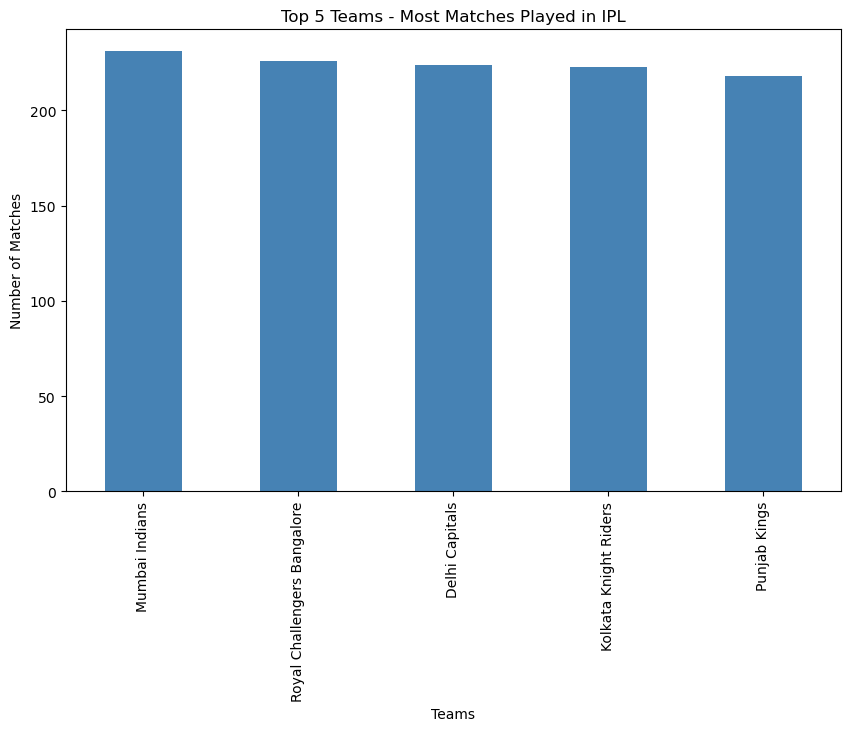

In [89]:
team1_counts = ipl['Team1'].value_counts()
team2_counts = ipl['Team2'].value_counts()

total_matches = team1_counts.add(team2_counts,fill_value = 0).astype(int)

top_5_teams = total_matches.sort_values(ascending = False).head(5)

print("Top 5 teams with maximum matches played:")
print(top_5_teams)

top_5_teams.plot(kind = 'bar',title = 'Top 5 Teams - Most Matches Played in IPL',
                 xlabel='Teams',
                 ylabel='Number of Matches',
                 figsize = (10,6),
                 color = 'steelblue')

### `Q-7:` Player who got Most no. of player of the match award playing against Mumbai Indians.
> Just for this question assume player of the match award is given to players from winning team. Although this is true in most of the cases.


In [92]:
team1_won = ipl[(ipl['Team2'] == 'Mumbai Indians') & (ipl['WinningTeam'] == ipl['Team1'])]
team2_won = ipl[(ipl['Team1'] == 'Mumbai Indians') & (ipl['WinningTeam'] == ipl['Team2'])]

mi_lost_matches = pd.concat([team1_won,team2_won])

print(f"Total matches where Mumbai Indians lost: {len(mi_lost_matches)}")

top_players = mi_lost_matches['Player_of_Match'].value_counts().head(10)

print("\nTop players with most 'Player of the Match' awards against Mumbai Indians:")
print(top_players)

best_player = top_players.idxmax()
max_awards = top_players.max()

print(f"\nPlayer with most awards against MI: {best_player} ({max_awards} awards)")

Total matches where Mumbai Indians lost: 100

Top players with most 'Player of the Match' awards against Mumbai Indians:
Player_of_Match
KL Rahul         4
SPD Smith        4
SK Raina         4
JC Buttler       3
JH Kallis        3
KC Sangakkara    3
V Sehwag         3
A Mishra         3
CH Gayle         3
A Nehra          3
Name: count, dtype: int64

Player with most awards against MI: KL Rahul (4 awards)


### `Q-8:` Team1 vs Team2 Dashbord
Create a function which will take two string(name of two teams) as input. Show win Loss record between them and player getting most player of the match award in matches between these two teams.
```
team1_vs_team2('Kolkata Knight Riders','Chennai Super Kings')
```

In [101]:
def team1_vs_team2(Team1,Team2):

    matches = ipl[((ipl['Team1'] == Team1) & (ipl['Team2'] == Team2)) | ((ipl['Team1'] == Team2) & (ipl['Team2'] == Team1))]
    total_matches = len(matches)
    if total_matches == 0:
        print(f"No matches found between {Team1} and {Team2}")
        return

    team1_wins = len(matches[matches['WinningTeam'] == Team1])
    team2_wins = len(matches[matches['WinningTeam'] == Team2])
    no_result = total_matches - team1_wins - team2_wins
    
    print(f"{'='*50}")
    print(f"     {Team1}  VS  {Team2}")
    print(f"{'='*50}")
    print(f"\nTotal Matches Played: {total_matches}")
    print(f"\n--- WIN/LOSS RECORD ---")
    print(f"{Team1}: {team1_wins} wins")
    print(f"{Team2}: {team2_wins} wins")
    if no_result > 0:
        print(f"No Result: {no_result}")
    print(f"\nWin % {Team1}: {(team1_wins/total_matches)*100:.1f}%")
    print(f"Win % {Team2}: {(team2_wins/total_matches)*100:.1f}%")
    
    # Most Player of the Match awards
    print(f"\n--- MOST 'PLAYER OF THE MATCH' AWARDS ---")
    top_players = matches['Player_of_Match'].value_counts().head(5)
    print(top_players)
    
    best_player = top_players.idxmax()
    best_count = top_players.max()
    print(f"\nMost awards: {best_player} ({best_count} awards)")
    print(f"{'='*50}")


team1_vs_team2('Kolkata Knight Riders', 'Chennai Super Kings')
    

     Kolkata Knight Riders  VS  Chennai Super Kings

Total Matches Played: 26

--- WIN/LOSS RECORD ---
Kolkata Knight Riders: 9 wins
Chennai Super Kings: 17 wins

Win % Kolkata Knight Riders: 34.6%
Win % Chennai Super Kings: 65.4%

--- MOST 'PLAYER OF THE MATCH' AWARDS ---
Player_of_Match
RA Jadeja       3
F du Plessis    2
MEK Hussey      2
UT Yadav        1
RA Tripathi     1
Name: count, dtype: int64

Most awards: RA Jadeja (3 awards)


### `Q-9:` Find out the top 7 cities where the matches of Kolkata Knight Riders are played frequently and plot the result as bar chart.

*`.plot(kind = "bar")` can help you to plot the bar chart. Also you can learn more about this method from [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)*



Top 7 cities wheere KKR played most matches: City
Kolkata      74
Mumbai       23
Abu Dhabi    14
Chennai      12
Bangalore    11
Delhi        10
Pune          9
Name: count, dtype: int64


<Axes: title={'center': 'Top 7 cities - Kolkata Knight Riders Mtches'}, xlabel='Cities', ylabel='Number of Matches'>

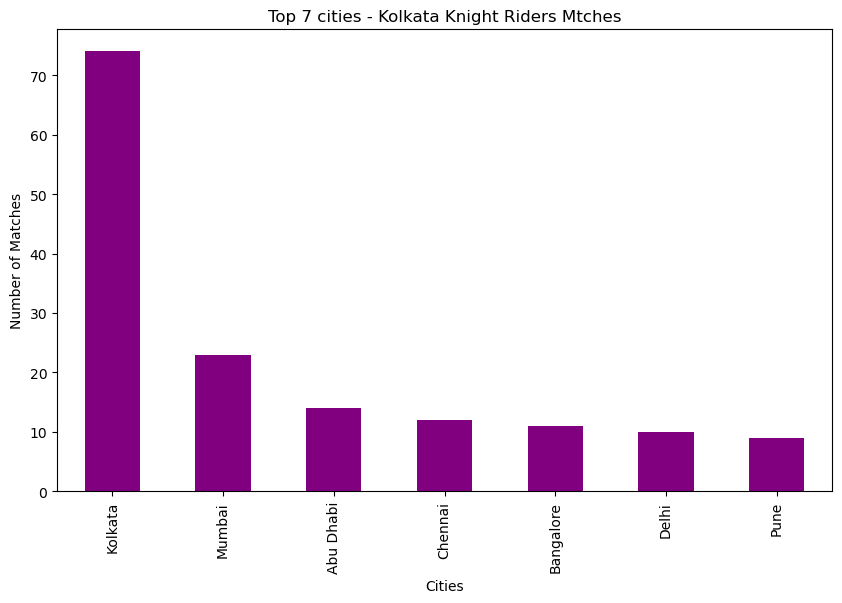

In [104]:
kkr_matches = ipl[(ipl['Team1'] == 'Kolkata Knight Riders') | (ipl['Team2'] == 'Kolkata Knight Riders')]

city_counts = kkr_matches['City'].value_counts().head(7)

print("Top 7 cities wheere KKR played most matches:",city_counts)

city_counts.plot(kind = 'bar',
                 title = "Top 7 cities - Kolkata Knight Riders Mtches",
                 xlabel = 'Cities',ylabel = 'Number of Matches',figsize = (10,6),color = 'purple')

### `Q-10:` Find out the average margin for the team Mumbai Indians for only the session 2011.

In [153]:
mi_2011 = ipl[(ipl['Season'] == 2011) & (ipl['WinningTeam'] == 'Mumbai Indians')].shape[0]
print("Total matches MI won in 2011:", mi_2011)

ipl['Season'] = ipl['Season'].astype(str).str.split('/').str[0].astype(int)

# Now filter by WonBy
runs_wins = ipl[ipl['WonBy'] == 'Runs']
wickets_wins = ipl[ipl['WonBy'] == 'Wickets']

avg_runs_margin = runs_wins['Margin'].mean()
avg_wickets_margin = wickets_wins['Margin'].mean()

print(f"\nMatches won by Runs: {len(runs_wins)}")
print(f"Average run margin: {avg_runs_margin:.2f} runs")

print(f"\nMatches won by Wickets: {len(wickets_wins)}")
print(f"Average wickets margin: {avg_wickets_margin:.2f} wickets")

Total matches MI won in 2011: 10

Matches won by Runs: 423
Average run margin: 30.07 runs

Matches won by Wickets: 509
Average wickets margin: 6.24 wickets
